### Precision-Recall Estimate HSDM DATA ###
With model and threshold for clip model

In [1]:
import sys
import os
import random
import numpy as np
import json
import copy
import glob
import pandas as pd
import logging
from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
from sklearn import metrics as skmetrics
import seaborn as sns

logger = logging.getLogger(__name__)

# PyTorch
import torch
from torchvision import ops

%load_ext autoreload
%autoreload 2
import computervision
from computervision.imageproc import is_image, ImageData, clipxywh, xyxy2xywh, xywh2xyxy, plot_boxes
from computervision.datasets import DETRdataset
from computervision.transformations import AugmentationTransform
from computervision.performance import DetectionMetrics
from computervision.inference import DETRinference, get_gpu_info

print(f'Project version: {computervision.__version__}')
print(f'Authors: {computervision.__authors__}')
print(f'Python version:  {sys.version}')

Project version: v0.0.2
Authors: The Core for Computational Biomedicine at Harvard Medical School
https://dbmi.hms.harvard.edu/about-dbmi/core-computational-biomedicine
Python version:  3.12.3 (main, Jun 18 2025, 17:59:45) [GCC 13.3.0]


In [3]:
# Check GPU availability
device, device_str = get_gpu_info()

CUDA available: True
Number of GPUs found:  1
Current device ID: 0
GPU device name:   NVIDIA GeForce RTX 3060 Laptop GPU
PyTorch version:   2.8.0a0+34c6371d24.nv25.08
CUDA version:      13.0
CUDNN version:     91200
Current device:    cuda:0


### Test data ###

In [4]:
# Test data
data_dir = os.environ.get('DATA')
dataset_name = 'dataset_object_240921'
image_dir = os.path.join(data_dir, dataset_name)
test_df_file_name = 'objectdata_240921_clean_ide_dset.parquet'
test_df_file = os.path.join(image_dir, test_df_file_name)
df = pd.read_parquet(test_df_file)

# Filter the data frame
dset_col = 'dset'
label_col = 'pos'
file_col = 'file_name'
bbox_col = 'bbox'
score_col = 'score'

df = df.loc[(df[dset_col].isin(['val', 'test']))]
display(df.head(2))
print(f'Images in test data: {len(df[file_col].unique())}')
print(f'Annotations:         {df.shape[0]}')

,file_name,width,height,bbox,pos,disease,dset
0,0060bce2_20210430_02.png,1200,854,"[204, 0, 620, 443]",14,unstable,val
1,0060bce2_20210430_02.png,1200,854,"[715, 409, 485, 445]",18,stable,val


Images in test data: 639
Annotations:         1129


### Model ###

In [10]:
print(checkpoint_dir)

/app/data_model/model/rtdetr_dtx_rbf_hsdm_251018_02/checkpoint-6240


In [12]:
model_name = 'rtdetr_dtx_rbf_hsdm_251018_02'
checkpoint = 6240
model_dir = os.path.join(data_dir, 'model', model_name)

# Output directory
output_dir = os.path.join(os.environ['DATA'], 'output', model_name, str(checkpoint))
Path(output_dir).mkdir(parents=True, exist_ok=True)
print(f'Output directory: {output_dir}')

checkpoint_dir = glob.glob(os.path.join(model_dir, f'checkpoint-{checkpoint}'))[0]
checkpoint_dict = {checkpoint: checkpoint_dir}
print(checkpoint_dict)

model_config_file = os.path.join(model_dir, f'{model_name}.json')
with open(model_config_file, mode='r') as file:
    model_config = json.load(file)
display(*list(model_config.keys()), sep='\n')

# Image processor
processor = DETRinference(device_name=device_str, 
                          checkpoint_path=checkpoint_dir).processor

Output directory: /app/data_model/output/rtdetr_dtx_rbf_hsdm_251018_02/6240
{6240: '/app/data_model/model/rtdetr_dtx_rbf_hsdm_251018_02/checkpoint-6240'}


'model_info'

'id2label'

'training_args'

'processor_params'

'bbox_format'

### PyTorch Dataset ###

In [13]:
# Create a PyTorch data set
transforms = AugmentationTransform().get_transforms(name='val')
bbox_format = model_config.get('bbox_format')
dataset = DETRdataset(data=df.copy(), 
                      image_processor=processor, 
                      image_dir=image_dir, 
                      file_name_col=file_col, 
                      label_id_col=None, 
                      bbox_col=None, 
                      bbox_format=bbox_format, 
                      transforms=transforms)
print(f'Total images in test data: {len(dataset)}')

# Convert the output image number id to the file name
file_name_list = [os.path.basename(file) for file in dataset.file_list]
id2file = dict(zip(range(len(file_name_list)), file_name_list))

# Convert the output category to the label (position)
id2label = {int(category_id): int(label) for category_id, label in model_config.get('id2label').items()}

# Add the data set labels to the data frame
dset_list = [list(df.loc[df[file_col] == file_name, dset_col].unique()) for file_name in file_name_list]
file2dset = dict(zip(file_name_list, dset_list))

Total images in test data: 639


### Predict bounding boxes on the test data for all checkpoints from this model ###

In [14]:
pred_file_name = f'{model_name}_hsdm_pred_{checkpoint}.parquet'
pred_file = os.path.join(output_dir, pred_file_name)
threshold = 0.05

if not os.path.exists(pred_file):

    print(f'Checkpoint {checkpoint}!')

    # Run the forward pass to get the predictions for all checkpoints
    pred_raw_list = []
    for c, (checkpoint, checkpoint_path) in enumerate(checkpoint_dict.items()):
        print(f'Running checkpoint {checkpoint} {c + 1} / {len(checkpoint_dict)}')
        dtr = DETRinference(device_name='cuda:0', 
                            checkpoint_path=checkpoint_dir,
                            batch_size=16)
        pred = dtr.predict_on_dataset(dataset, threshold=threshold)
        pred = pred.assign(checkpoint=checkpoint, pred_threshold=threshold)
        pred_raw_list.append(pred)
    
    pred_raw = pd.concat(pred_raw_list, axis=0, ignore_index=True).\
        sort_values(by='checkpoint', ascending=True).\
        reset_index(drop=True)
    
    # Make a copy of the predictions 
    pred = copy.deepcopy(pred_raw)
    
    # Add the file names to the data frame
    pred[file_col] = pred['image_id'].apply(lambda image_id: id2file.get(image_id))
    
    # Add the label names (the positions) to the data frame
    pred[label_col] = pred['category_id'].apply(lambda category_id: id2label.get(category_id))
    
    # Add the data sets for each image
    pred[dset_col] = pred[file_col].apply(lambda file_name: file2dset.get(file_name))

    # Let's find out if all of the images resulted in predictions
    pred_empty = len(pred.loc[pred[label_col].isnull(), file_col].unique())
    print(f'Images without predictions for threshold ({threshold}):{pred_empty}')
    
    # Filter out rows with images that do not have predictions
    pred = pred.loc[~pred[label_col].isnull()]
    
    # Save the predictions
    pred.to_parquet(pred_file)
    print(f'Saved output to file: {pred_file}')

else:
    
    print(f'Loading from file: {pred_file}')
    pred = pd.read_parquet(pred_file)

print(f'Total number of images in data set:             {len(dataset)}')
print(f'Images with predictions:                        {len(pred[file_col].unique())}')

Checkpoint 6240!
Running checkpoint 6240 1 / 1
Predicting batch 10 of 40.
Predicting batch 20 of 40.
Predicting batch 30 of 40.
Predicting batch 40 of 40.
Images without predictions for threshold (0.05):0
Saved output to file: /app/data_model/output/rtdetr_dtx_rbf_hsdm_251018_02/6240/rtdetr_dtx_rbf_hsdm_251018_02_hsdm_pred_6240.parquet
Total number of images in data set:             639
Images with predictions:                        639


### Classify predictions: TP, FP, FN ###
We create a method to classify all of the predictions in the data set. 

In [15]:
true_df = copy.deepcopy(df)
pred_df = copy.deepcopy(pred)
display(pred_df.head(2))

,image_id,image_width,image_height,batch,category_id,bbox,score,area,checkpoint,pred_threshold,file_name,pos,dset
0,0,1200,854,0,14,"[601, 1, 590, 288]",0.224381,169920,6240,0.05,0060bce2_20210430_02.png,15,[val]
1,423,854,1200,26,7,"[71, 1, 376, 1199]",0.181069,450824,6240,0.05,9e61a7c7_20210227_10.png,8,[val]


In [16]:
pr_df_list = []
ap_df_list = []

iou_list = [0.25, 0.5, 0.75]
    
pred_df_checkpoint = pred_df.loc[pred_df['checkpoint'] == checkpoint]

# Set up the metrics instance
metrics = DetectionMetrics(
true_df=true_df,
pred_df=pred_df_checkpoint,
file_col=file_col,
label_col=label_col,
bbox_col=bbox_col,
score_col=score_col)

for iou_threshold in iou_list:

    # Classify the predictions
    classifications, missed = metrics.classify_predictions_df(iou_threshold=iou_threshold)
    pr_df = metrics.ap_from_classifications(classifications=classifications)
    pr_df.insert(loc=0, column='model', value=model_name)
    pr_df.insert(loc=1, column='dataset', value=dataset_name)
    pr_df.insert(loc=2, column='checkpoint', value=checkpoint)
    pr_df.insert(loc=3, column='score_threshold', value=threshold)
    pr_df_list.append(pr_df)
    
    # Get the AUC values
    ap_df = pr_df[[label_col, 'iou_threshold', 'auc', file_col]].\
        groupby([label_col, 'iou_threshold', 'auc']).nunique().\
        reset_index(drop=False).\
        rename(columns={file_col: 'n_predictions'}).\
        sort_values(by=label_col, ascending=True).\
        reset_index(drop=True)
    ap_df.insert(loc=0, column='model', value=model_name)
    ap_df.insert(loc=1, column='dataset', value=dataset_name)
    ap_df.insert(loc=2, column='checkpoint', value=checkpoint)
    ap_df.insert(loc=3, column='score_threshold', value=threshold)
    print(f'mAP for checkpoint {checkpoint} at IoU({iou_threshold}): {ap_df['auc'].mean(): .3f}')
    ap_df_list.append(ap_df)

mAP for checkpoint 6240 at IoU(0.25):  0.248
mAP for checkpoint 6240 at IoU(0.5):  0.151
mAP for checkpoint 6240 at IoU(0.75):  0.003


In [17]:
# Save the output
precision_recall_df = pd.concat(pr_df_list, axis=0, ignore_index=True)
average_precision_df = pd.concat(ap_df_list, axis=0, ignore_index=True)

pr_data_name = f'{model_name}_hsdm_PR.parquet'
pr_data_file = os.path.join(output_dir, pr_data_name)
precision_recall_df.to_parquet(pr_data_file)
print(f'Saved Precision-Recall data: {pr_data_file}')

ap_data_name = f'{model_name}_hsdm_AUC.parquet'
ap_data_file = os.path.join(output_dir, ap_data_name)
average_precision_df.to_parquet(ap_data_file)
print(f'Saved Average Precision data: {ap_data_file}')

display(precision_recall_df.head(2))
display(average_precision_df.head(2))

Saved Precision-Recall data: /app/data_model/output/rtdetr_dtx_rbf_hsdm_251018_02/6240/rtdetr_dtx_rbf_hsdm_251018_02_hsdm_PR.parquet
Saved Average Precision data: /app/data_model/output/rtdetr_dtx_rbf_hsdm_251018_02/6240/rtdetr_dtx_rbf_hsdm_251018_02_hsdm_AUC.parquet


,model,dataset,checkpoint,score_threshold,file_name,iou_threshold,score,bbox,pos,TP,IoU,n_missed,duplicate_TP,precision,recall,precision_label,recall_label,auc
0,rtdetr_dtx_rbf_hsdm_251018_02,dataset_object_240921,6240,0.05,4d47eb4b_20230131_00.png,0.25,0.191544,"[197, 6, 790, 1016]",1,0,NaN,0,False,NaN,NaN,NaN,NaN,NaN
1,rtdetr_dtx_rbf_hsdm_251018_02,dataset_object_240921,6240,0.05,7d05af8e_20210517_16.png,0.25,0.183143,"[9, 392, 1084, 821]",1,0,NaN,0,False,NaN,NaN,NaN,NaN,NaN


,model,dataset,checkpoint,score_threshold,pos,iou_threshold,auc,n_predictions
0,rtdetr_dtx_rbf_hsdm_251018_02,dataset_object_240921,6240,0.05,2,0.25,0.317770,126
1,rtdetr_dtx_rbf_hsdm_251018_02,dataset_object_240921,6240,0.05,3,0.25,0.384261,126


### Image-level results: precision - recall for labeled objects ###

In [18]:
#min_score = 0.17
cl_list = sorted(df[label_col].unique())
score_threshold_list = np.arange(0.020, 0.5, 0.010)
iou_threshold = 0.25

result_df_list = []
print(f'Checkpoint {checkpoint}')

prdata = copy.deepcopy(precision_recall_df)
prdata = prdata.loc[
    (prdata['checkpoint'] == checkpoint) & 
    (prdata['iou_threshold'] == iou_threshold)]

# LOOP OVER ALL CLASSES
for c, cl in enumerate(cl_list):

    if (c + 1) % 10 == 0:
        print(f'Label {c + 1} / {len(cl_list)}')

    # Images with labels for that class
    true_cl_images = sorted(list(df.loc[df[label_col] == cl, file_col].unique()))
    
    if len(true_cl_images) > 0:

        # Count the predictions for different thresholds
        for m, min_score in enumerate(score_threshold_list):
    
            # Check each images if the class was predicted
            predicted_cl = []
            total_predictions_cl = []
            
            for file_name in true_cl_images:
            
                # Check im the class is in the prediction for the given treshold
                pr_cl_list = prdata.loc[
                    (prdata[file_col] == file_name) &
                    (prdata[label_col] == cl) &
                    (prdata[score_col] >= min_score), 
                    label_col].tolist()
                
                prediction = 0 # FN: the class was missed in this image
                
                if len(pr_cl_list) > 0:
                    # The class was predicted in this image
                    prediction = 1
    
                total_predictions_cl.append(len(pr_cl_list))
                predicted_cl.append(prediction)
            
            # Confusion matrix
            total_cl = sum(total_predictions_cl)
            n_cl = len(predicted_cl)
            FP_cl = total_cl - n_cl # multiple predictions
            TP_cl = sum(predicted_cl)
            FN_cl = n_cl - TP_cl # prediction=0
            RC_cl = np.around(TP_cl / n_cl, decimals=3)
    
            result_cl = {'model': model_name, 
                         'checkpoint': checkpoint,
                         'score_threshold': min_score,
                         label_col: cl,
                         'n_true_images': n_cl,
                         'total_preds': total_cl,
                         'mulitples': FP_cl,
                         'TP': TP_cl,
                         'FN': FN_cl,
                         'recall': RC_cl}
        
            result_df_list.append(pd.DataFrame(result_cl, index=[c]))
    
result_df = pd.concat(result_df_list, axis=0)

# Save the recall table
rc_data_name = f'{model_name}_hsdm_RECALL.parquet'
rc_data_file = os.path.join(output_dir, rc_data_name)
result_df.to_parquet(rc_data_file)
print(f'Saved recall results: {rc_data_file}')

Checkpoint 6240
Label 10 / 31
Label 20 / 31
Label 30 / 31
Saved recall results: /app/data_model/output/rtdetr_dtx_rbf_hsdm_251018_02/6240/rtdetr_dtx_rbf_hsdm_251018_02_hsdm_RECALL.parquet


In [19]:
metric = 'recall'
label_list = sorted(list(result_df['pos'].unique()))

data_metric = result_df[['checkpoint', 'score_threshold', metric]].\
    groupby(['checkpoint', 'score_threshold']).mean().\
    reset_index(drop=False).\
    sort_values(by=['checkpoint', 'score_threshold'], ascending=True).\
    reset_index(drop=True)

display(data_metric.sample(5))

,checkpoint,score_threshold,recall
5,6240,0.07,0.863935
6,6240,0.08,0.805548
11,6240,0.13,0.519355
40,6240,0.42,0.000000
27,6240,0.29,0.008677


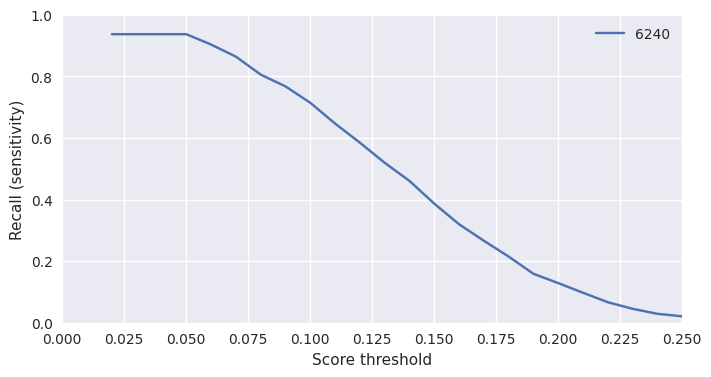

In [20]:
plt.style.use('seaborn-v0_8')
checkpoints = sorted(list(data_metric['checkpoint'].unique()))

fig, ax = plt.subplots(figsize=(8, 4))

for checkpoint in checkpoints:

    data_checkpoint = data_metric.loc[data_metric['checkpoint'] == checkpoint]

    x_data = data_checkpoint['score_threshold'].tolist()
    y_data = data_checkpoint[metric].tolist()
    
    ax.set(xlim=[0, 0.250], xticks=np.arange(0, 0.275, 0.025))
    ax.set(ylim=[0, 1.0], yticks=np.arange(0, 1.2, 0.2))
    ax.set(xlabel='Score threshold', ylabel='Recall (sensitivity)')
    
    ax.plot(x_data, y_data, label=checkpoint)
    ax.legend(loc='upper right')

recall_graph_name = f'{model_name}_hsdm_recall.png'
recall_graph_file = os.path.join(output_dir, recall_graph_name)

plt.savefig(recall_graph_file)
plt.show()

### Visualizations: bounding boxes ###

In [39]:
file_list = sorted(list(pr_df[file_col].unique()))
random.shuffle(file_list)
show_n_images = 10
min_score = 0.1

output_images_dir = os.path.join(output_dir, 'images')
Path(output_images_dir).mkdir(parents=True, exist_ok=True)
print(f'Total number of images in data: {len(file_list)}')

Total number of images in data: 639


IMAGE 1 / 639


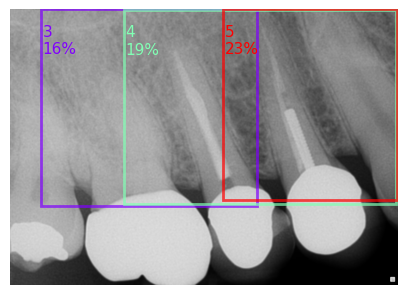

IMAGE 2 / 639


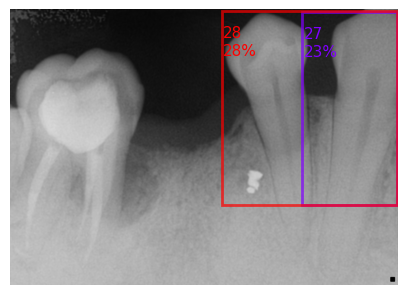

IMAGE 3 / 639


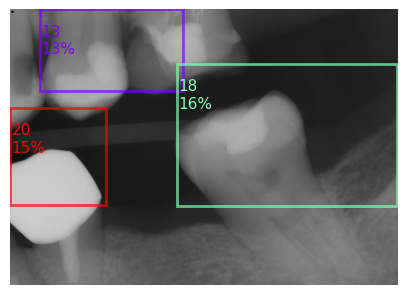

IMAGE 4 / 639


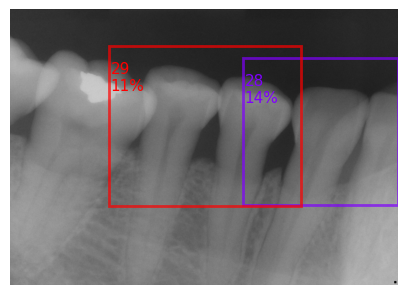

IMAGE 5 / 639


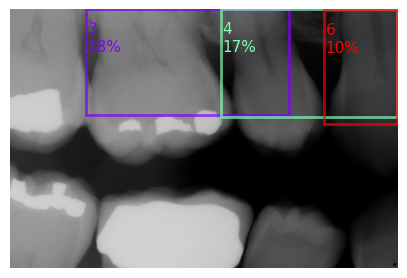

IMAGE 6 / 639


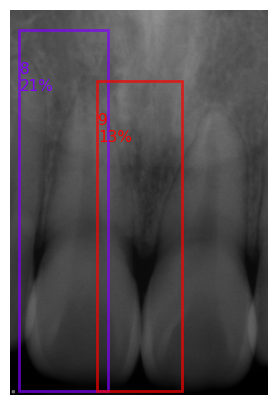

IMAGE 7 / 639


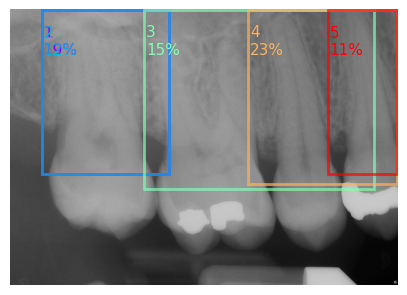

IMAGE 8 / 639


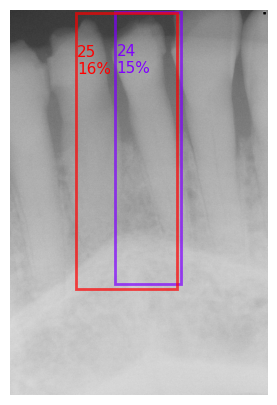

IMAGE 9 / 639


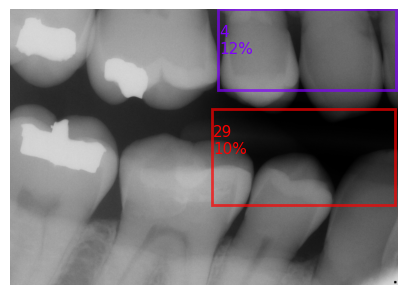

IMAGE 10 / 639


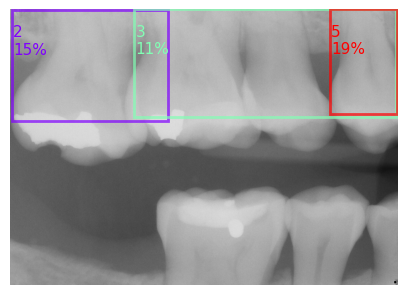

In [40]:
for f, file_name in enumerate(file_list[:show_n_images]):

    print(f'IMAGE {f + 1} / {len(file_list)}')
    
    file = os.path.join(image_dir, file_name)
    im = ImageData().load_image(file)
    im = ImageData().np2color(im)
    # im = ImageData().hist_eq(im)
    
    # Create a file name to save the image
    im_file_name = f'{model_name}_{checkpoint}_{os.path.splitext(file_name)[0]}.png'
    im_file = os.path.join(output_images_dir, im_file_name)
    
    pr_file = pr_df.loc[(pr_df[file_col] == file_name) & (pr_df[score_col] >= min_score)]
    
    # Take the prediction with the higher score if there is more than one
    pr_file = pr_file.sort_values(by=[label_col, score_col], ascending=False).\
        groupby(label_col).first().\
        reset_index(drop=False)
    
    pr_bbox_list = pr_file[bbox_col].tolist()
    pr_pos_list = pr_file[label_col].tolist()
    pr_score_list = pr_file[score_col].tolist()
    pr_label_list = [f'{pos}\n{str(int(score*100)).zfill(2)}%' for pos, score in zip(pr_pos_list, pr_score_list)]
    
    df_file = df.loc[df[file_col] == file_name]
    df_bbox_list = df_file[bbox_col].tolist()
    df_pos_list = df_file[label_col].tolist()
    
    fig, ax = plt.subplots(figsize=(5, 5))
    
    #ax = plot_boxes(image=im, 
    #                box_list=df_bbox_list, 
    #                label_list=df_pos_list, 
    #                ax=ax, 
    #                color='w', 
    #                linewidth=2.0, 
    #                fontsize=11)
    
    ax = plot_boxes(image=im, 
                    box_list=pr_bbox_list, 
                    label_list=pr_label_list, 
                    ax=ax, 
                    offset_xy=(0, 100), 
                    linewidth=2.0, 
                    fontsize=11)
    
    plt.savefig(im_file, bbox_inches='tight')
    plt.show()

### Visualizations: PR Curves ###

In [41]:
min_score = 0.1
iou_threshold = 0.5
pr_df = precision_recall_df.loc[precision_recall_df['checkpoint'] == checkpoint]
iou_list = sorted(list(pr_df['iou_threshold'].unique()))
print(iou_list)

plt.style.use('seaborn-v0_8')
cmap = plt.cm.Blues
num_colors = len(iou_list) + 1
colors = [cmap(i) for i in np.linspace(0.6, 1, num_colors)]

output_pr_dir = os.path.join(output_dir, 'pr')
Path(output_pr_dir).mkdir(parents=True, exist_ok=True)

[0.25, 0.5, 0.75]


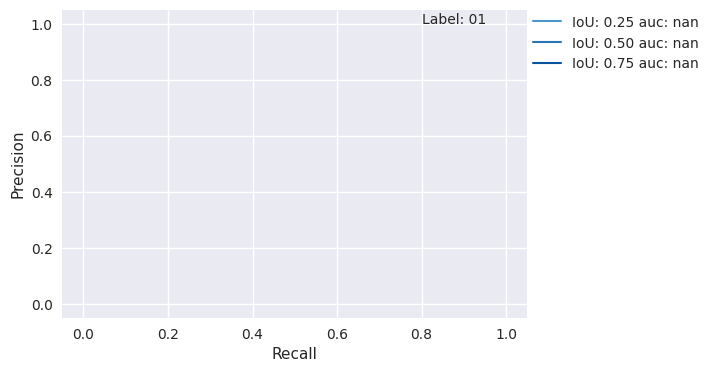

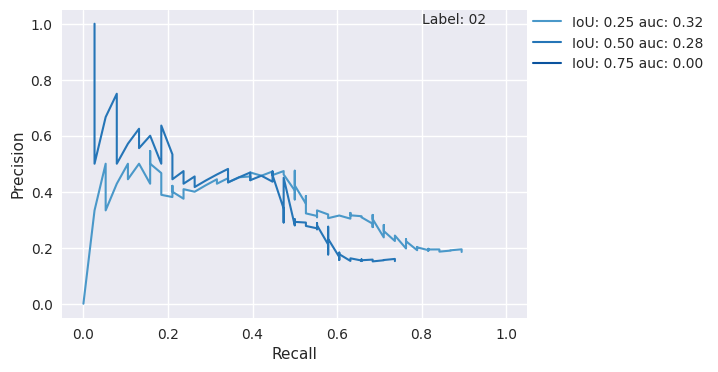

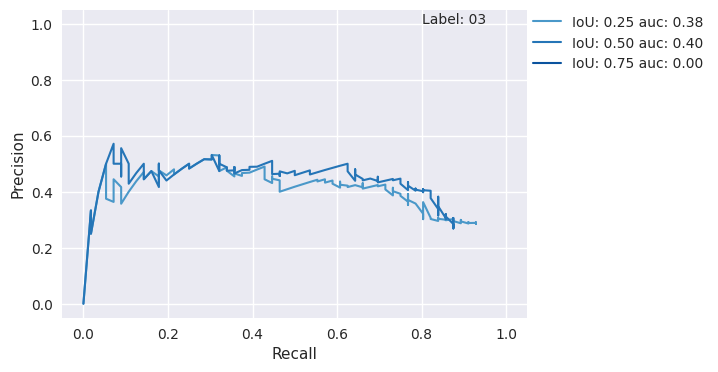

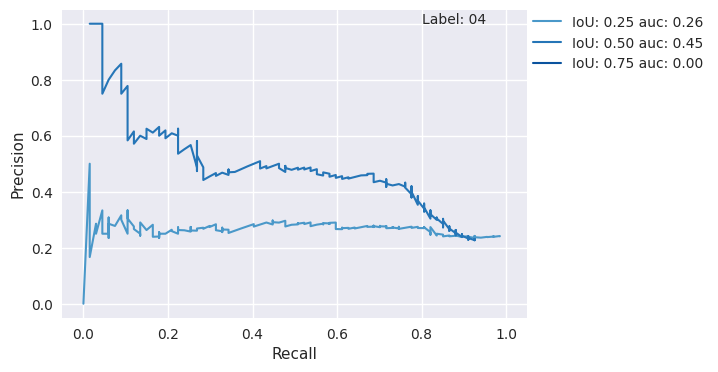

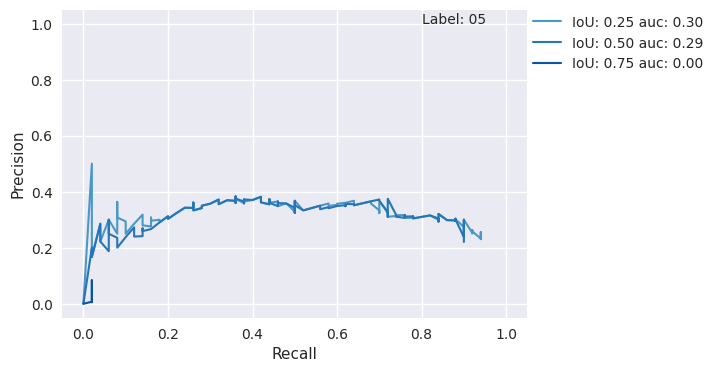

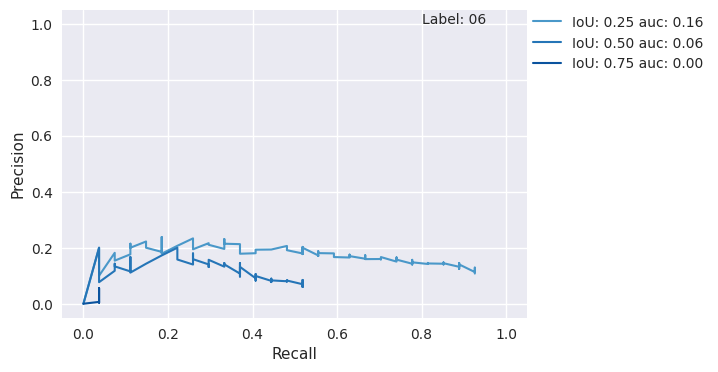

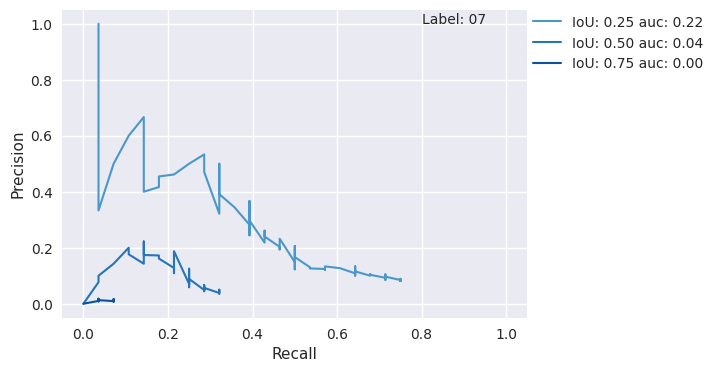

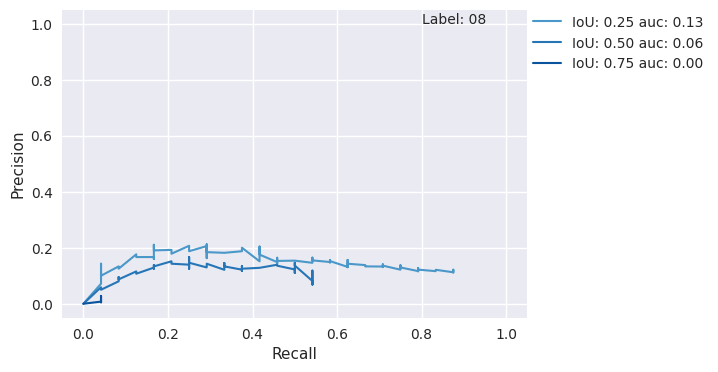

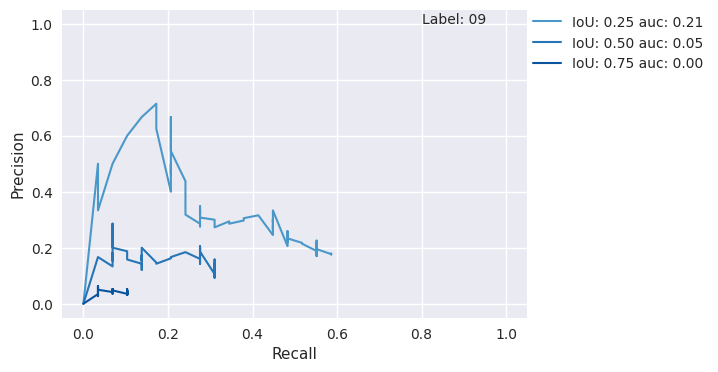

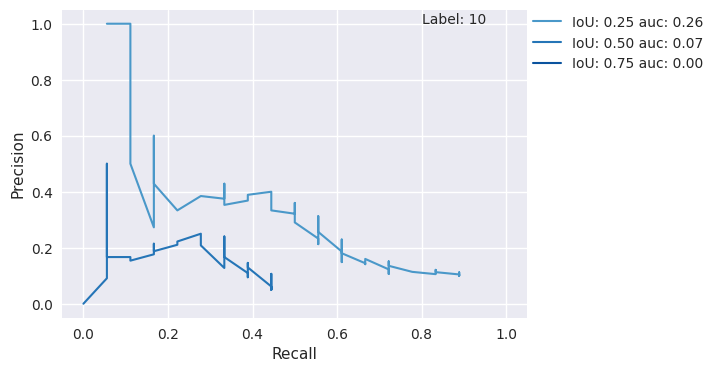

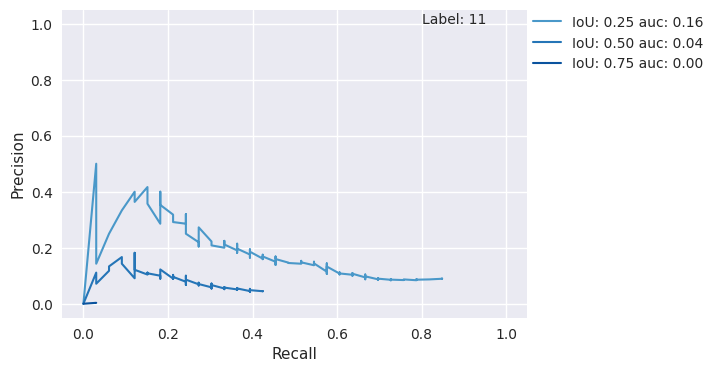

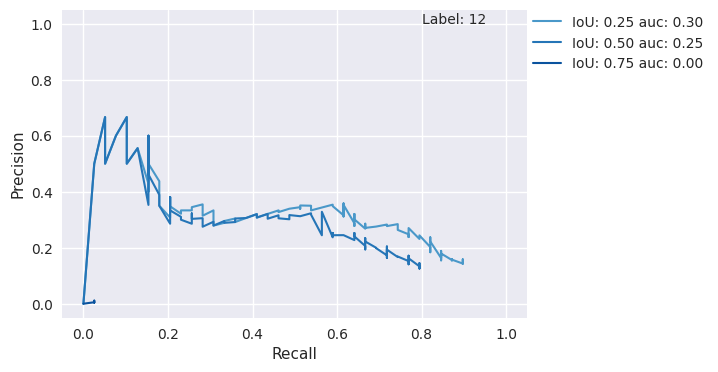

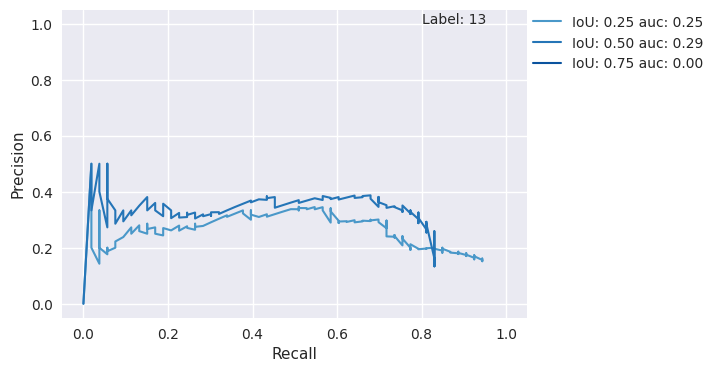

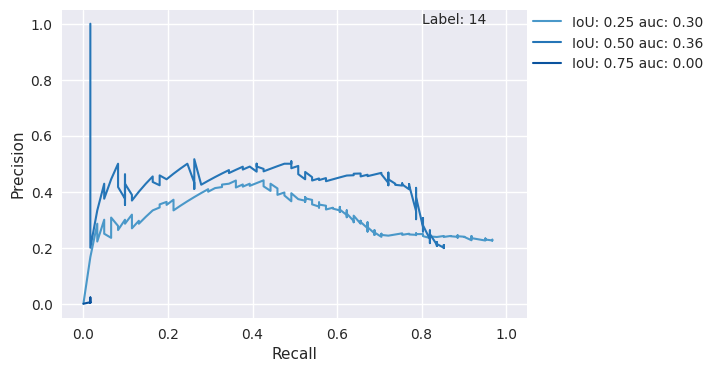

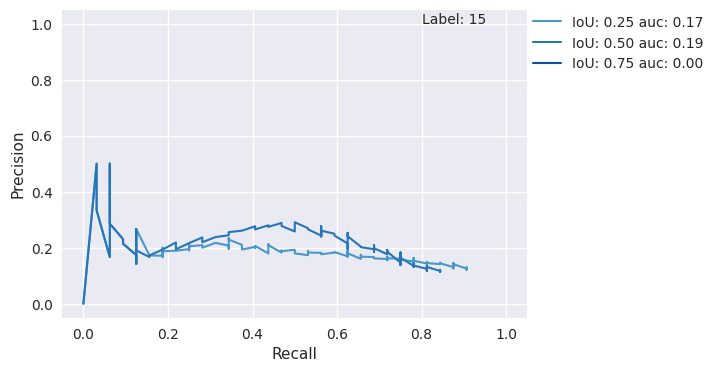

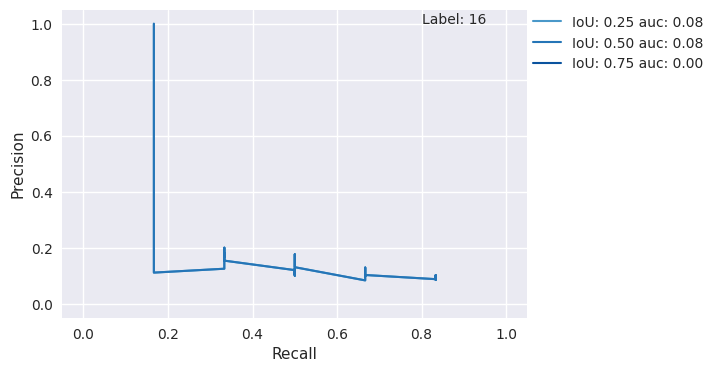

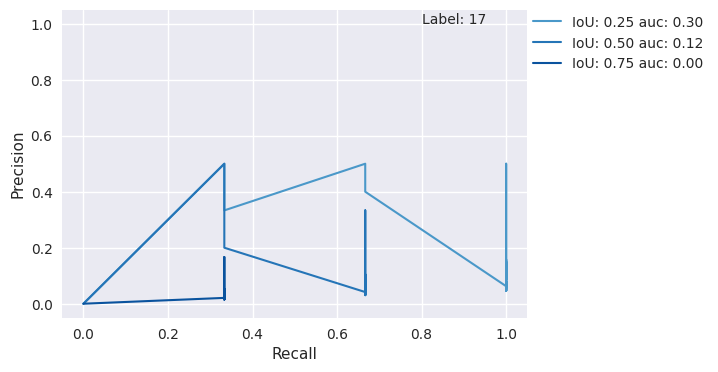

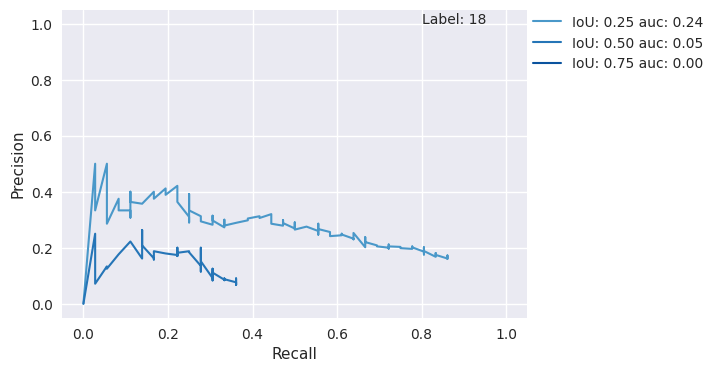

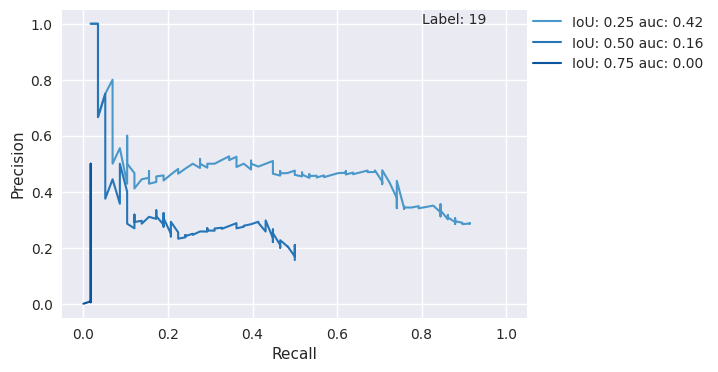

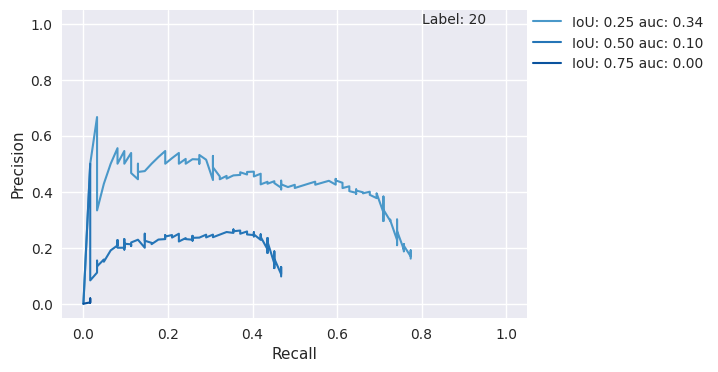

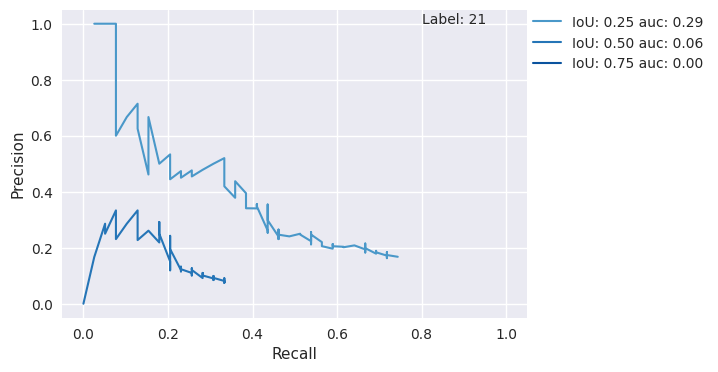

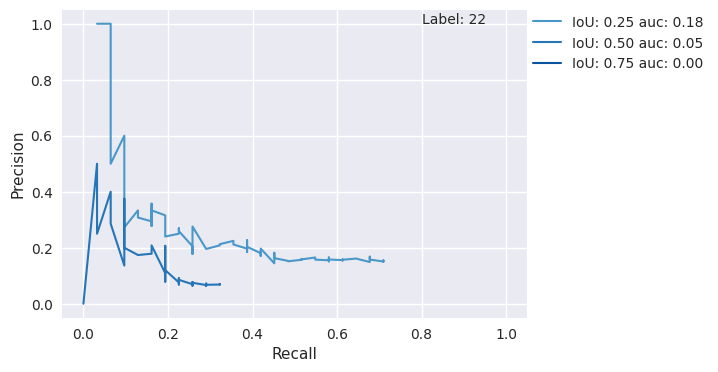

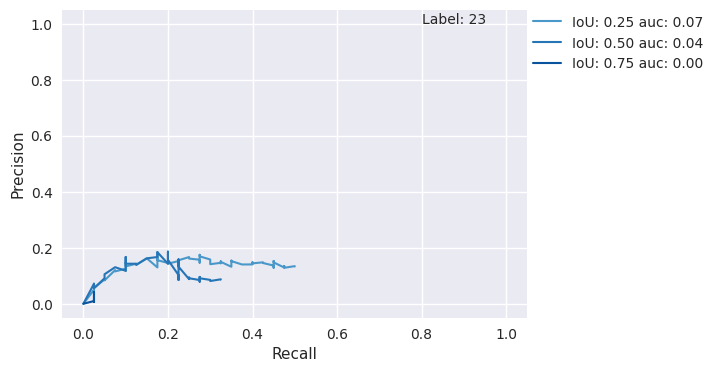

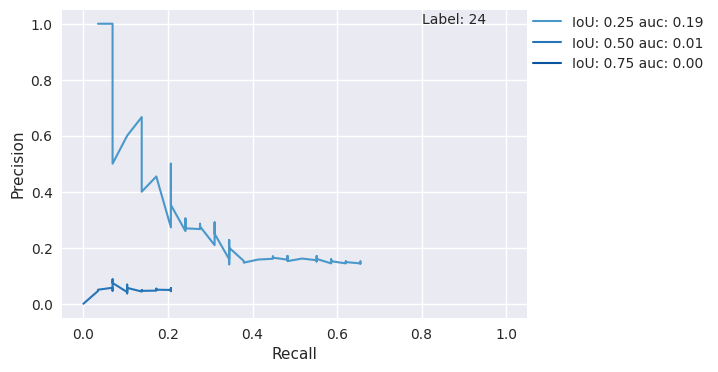

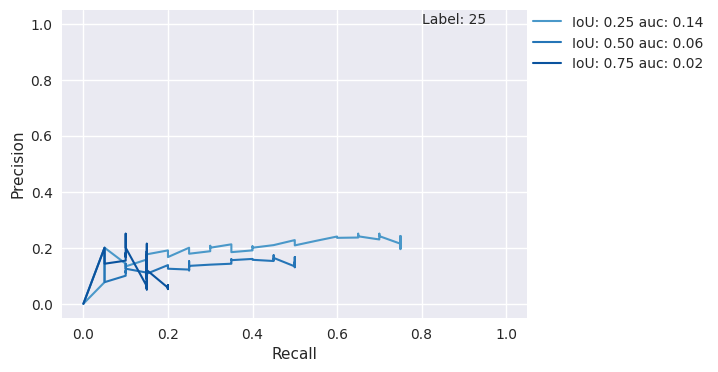

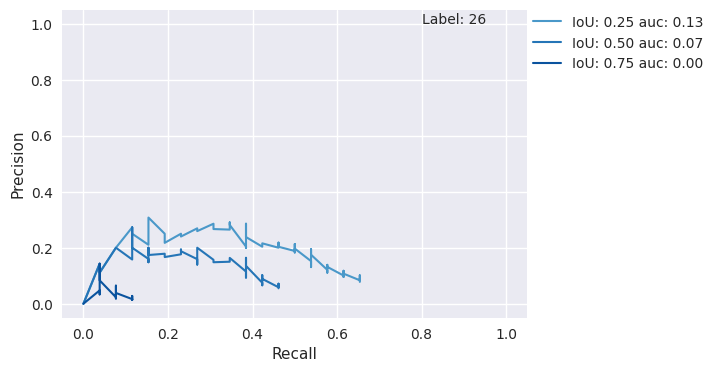

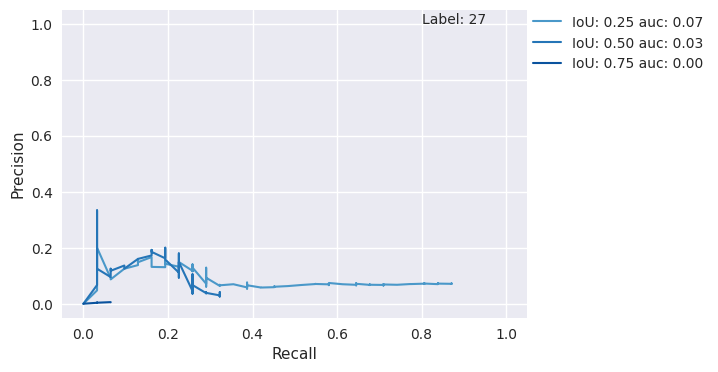

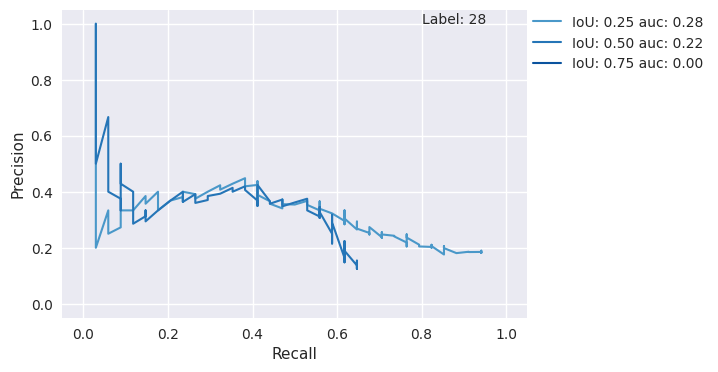

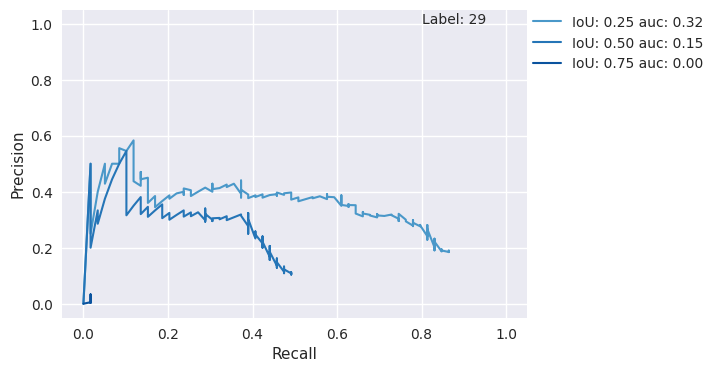

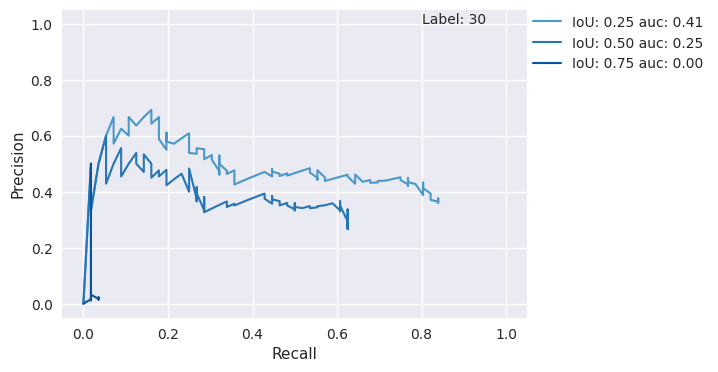

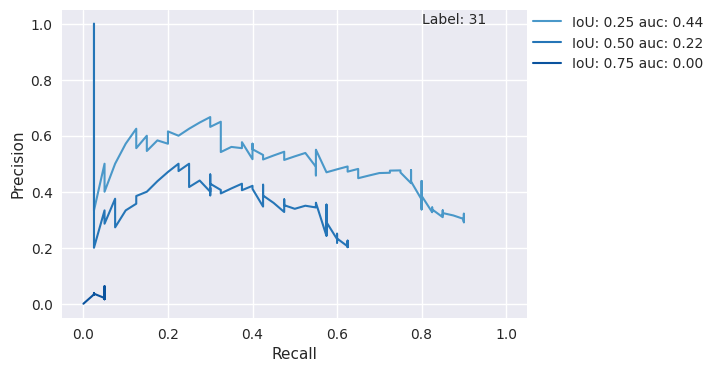

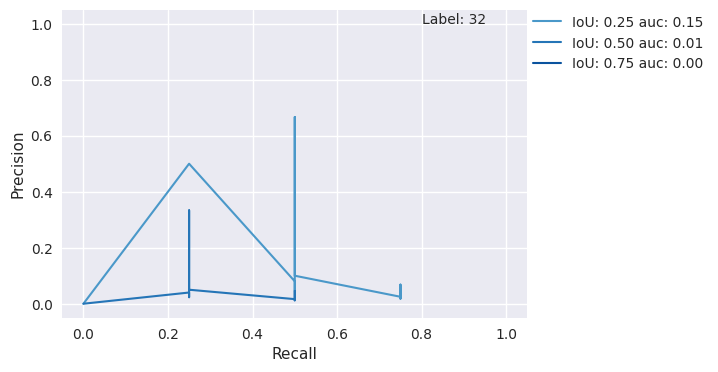

In [42]:
label_list = sorted(list(pr_df[label_col].unique()))

for label in label_list:

    # l = 10
    # label = label_list[l]
    
    fig_file_name = f'{model_name}_{str(label).zfill(2)}.png'
    fig_file = os.path.join(output_pr_dir, fig_file_name)
    
    fig, ax = plt.subplots(figsize=(6, 4))
    
    for c, iou in enumerate(iou_list):
    
        pr_df_label = pr_df.loc[
                (pr_df[label_col] == label) & 
                (pr_df['iou_threshold'] == iou)].\
            sort_values(by='recall', ascending=True).\
            reset_index(drop=True)
        
        prec = pr_df_label['precision'].tolist()
        rec = pr_df_label['recall'].tolist()
        auc = skmetrics.auc(x=rec, y=prec)
        graph_label = f'IoU:{iou: .2f} auc:{auc: .2f}'
        
        ax.plot(rec, prec, linewidth=1.5, label=graph_label, color=colors[c])
        
        ax.set(xlim=[-0.05, 1.05], xticks=np.arange(0, 1.2, 0.2),
               ylim=[-0.05, 1.05], yticks=np.arange(0, 1.2, 0.2),
               xlabel='Recall', ylabel='Precision')
    
        ax.legend(bbox_to_anchor=(1, 1), loc='upper left', borderaxespad=0.)
        
    ax.text(x=0.80, y=1.0, s=f'Label: {str(label).zfill(2)}', size=10)
    plt.savefig(fig_file, bbox_inches='tight')
    plt.show()